Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Generating splits...:   0%|          | 0/3 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/pneumonia_mnist/incomplete.F4M07Z_1.0.0/pneumonia_mnist-train.tfrecord*...…

...

Shuffling /root/tensorflow_datasets/pneumonia_mnist/incomplete.F4M07Z_1.0.0/pneumonia_mnist-val.tfrecord*...: …

Generating test examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/pneumonia_mnist/incomplete.F4M07Z_1.0.0/pneumonia_mnist-test.tfrecord*...:…

Dataset pneumonia_mnist downloaded and prepared to /root/tensorflow_datasets/pneumonia_mnist/1.0.0. Subsequent calls will reuse this data.

Processing and saving images to pneumoniamnist_dataset...


Saving train set:   0%|          | 0/4708 [00:00<?, ?it/s]/tmp/ipython-input-268801112.py:53: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  img = Image.fromarray(image_array, mode='L')
Saving test set: 100%|██████████| 624/624 [00:00<00:00, 1473.73it/s]


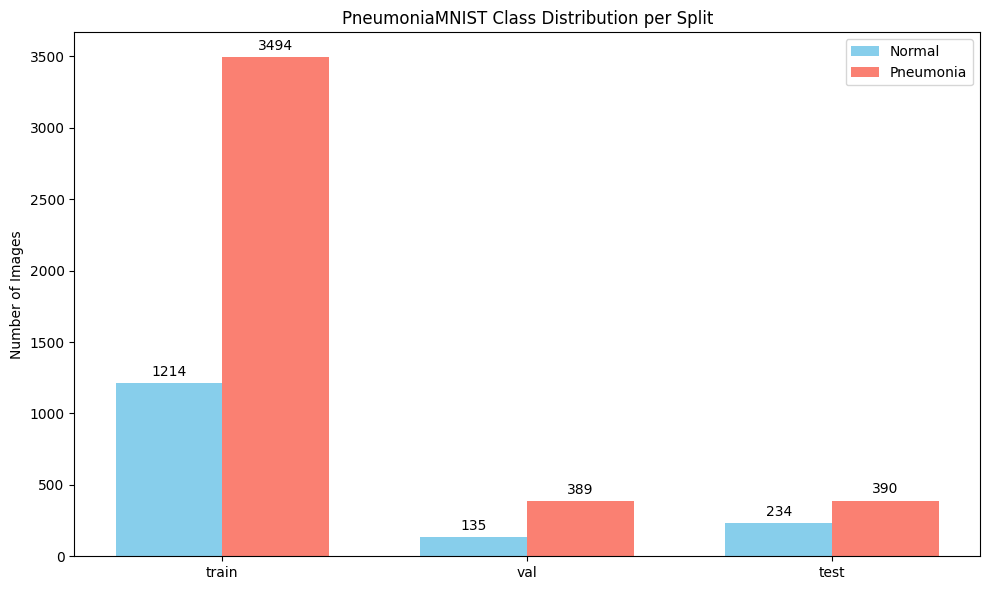

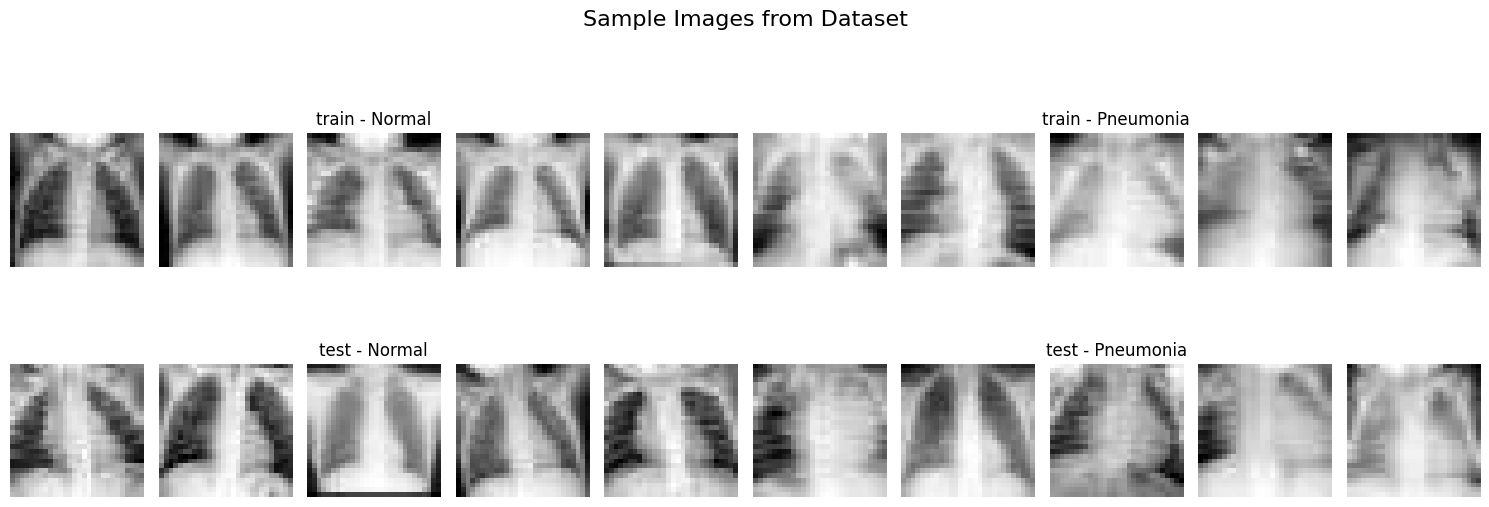


Dataset is ready at: /content/pneumoniamnist_dataset


In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import tensorflow_datasets as tfds
from PIL import Image
from tqdm import tqdm

def prepare_pneumoniamnist_data():
    # 1. Load the dataset from TensorFlow Datasets
    print("Downloading PneumoniaMNIST...")
    ds, info = tfds.load('pneumonia_mnist', with_info=True, as_supervised=True)

    # Define class names based on documentation (0=Normal, 1=Pneumonia)
    class_names = {0: 'Normal', 1: 'Pneumonia'}

    # Define splits to process
    splits = ['train', 'val', 'test']

    # Root directory for saving images
    base_dir = 'pneumoniamnist_dataset'

    # Dictionaries to store counts for plotting later
    stats = {split: {'Normal': 0, 'Pneumonia': 0} for split in splits}

    print(f"\nProcessing and saving images to {base_dir}...")

    for split in splits:
        # Create directories: dataset/train/Normal, dataset/train/Pneumonia, etc.
        for label_code, label_name in class_names.items():
            os.makedirs(os.path.join(base_dir, split, label_name), exist_ok=True)

        # Iterate through the TFDS dataset
        # We use standard 'val' key as shown in your screenshot, but TFDS often uses 'validation'
        # Adjusting key if necessary based on your screenshot showing 'val'
        tfds_split_name = 'validation' if split == 'val' and 'validation' in ds else split

        dataset_iterator = ds[tfds_split_name]

        for i, (image_tensor, label_tensor) in tqdm(enumerate(dataset_iterator),
                                                    desc=f"Saving {split} set",
                                                    total=info.splits[tfds_split_name].num_examples):

            label_code = label_tensor.numpy()
            label_name = class_names[label_code]

            # Convert tensor to PIL Image
            # The image is 28x28x1 (grayscale), we convert to 'L' mode
            image_array = image_tensor.numpy()
            if image_array.shape[-1] == 1:
                image_array = image_array.squeeze()

            img = Image.fromarray(image_array, mode='L')

            # Save image
            filename = f"{label_name}_{i}.png"
            save_path = os.path.join(base_dir, split, label_name, filename)
            img.save(save_path)

            # Update stats
            stats[split][label_name] += 1

    return stats, base_dir

def plot_data_distribution(stats):
    splits = list(stats.keys())
    normal_counts = [stats[s]['Normal'] for s in splits]
    pneumonia_counts = [stats[s]['Pneumonia'] for s in splits]

    x = np.arange(len(splits))
    width = 0.35

    fig, ax = plt.subplots(figsize=(10, 6))
    rects1 = ax.bar(x - width/2, normal_counts, width, label='Normal', color='skyblue')
    rects2 = ax.bar(x + width/2, pneumonia_counts, width, label='Pneumonia', color='salmon')

    ax.set_ylabel('Number of Images')
    ax.set_title('PneumoniaMNIST Class Distribution per Split')
    ax.set_xticks(x)
    ax.set_xticklabels(splits)
    ax.legend()

    # Add counts on top of bars
    def autolabel(rects):
        for rect in rects:
            height = rect.get_height()
            ax.annotate(f'{height}',
                        xy=(rect.get_x() + rect.get_width() / 2, height),
                        xytext=(0, 3),  # 3 points vertical offset
                        textcoords="offset points",
                        ha='center', va='bottom')

    autolabel(rects1)
    autolabel(rects2)
    plt.tight_layout()
    plt.show()

def display_samples(base_dir):
    splits = ['train', 'test']
    classes = ['Normal', 'Pneumonia']

    fig, axes = plt.subplots(len(splits), len(classes) * 5, figsize=(15, 6))
    plt.suptitle("Sample Images from Dataset", fontsize=16)

    for row_idx, split in enumerate(splits):
        col_idx = 0
        for cls in classes:
            folder_path = os.path.join(base_dir, split, cls)
            images = os.listdir(folder_path)[:5] # Take first 5 images

            for img_name in images:
                img_path = os.path.join(folder_path, img_name)
                img = Image.open(img_path)

                ax = axes[row_idx, col_idx]
                ax.imshow(img, cmap='gray')
                ax.axis('off')
                if col_idx % 5 == 2: # Title only on the middle image of the group
                    ax.set_title(f"{split} - {cls}")
                col_idx += 1
    plt.tight_layout()
    plt.show()

# --- EXECUTION ---
# 1. Download and Save
stats, dataset_path = prepare_pneumoniamnist_data()

# 2. Plot Counts
plot_data_distribution(stats)

# 3. Display Samples
display_samples(dataset_path)

print(f"\nDataset is ready at: {os.path.abspath(dataset_path)}")

In [2]:
!git clone https://github.com/AnasHXH/Task_1.git

Cloning into 'Task_1'...
remote: Enumerating objects: 84, done.
remote: Counting objects: 100% (84/84), done.
remote: Compressing objects: 100% (77/77), done.
remote: Total 84 (delta 33), reused 12 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (84/84), 337.14 KiB | 1.84 MiB/s, done.
Resolving deltas: 100% (33/33), done.


# Training Pre-train Model and use Decomposition method

In [3]:
%cd /content/Task_1/task1_classification

!python train_decomposition.py\
     --data_dir /content/pneumoniamnist_dataset\
         --output_dir results_decom\
             --batch_size 4 --epochs 32 --learning_rate 0.0001

/content/Task_1/task1_classification
Training on device: cuda:0

Applying Class Decomposition to balance the dataset...
Extracting features to split Pneumonia into 2 clusters using CLIP...
preprocessor_config.json: 100% 316/316 [00:00<00:00, 1.27MB/s]
The image processor of type `CLIPImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 
config.json: 4.19kB [00:00, 13.4MB/s]
tokenizer_config.json: 100% 592/592 [00:00<00:00, 4.16MB/s]
vocab.json: 862kB [00:00, 24.8MB/s]
merges.txt: 525kB [00:00, 74.5MB/s]
tokenizer.json: 2.22MB [00:00, 75.4MB/s]
special_tokens_map.json: 100% 389/389 [00:00<00:00, 2.18MB/s]
pytorch_model.bin: 100% 605M/605M [00:03<00:00, 188MB/s]
Loading weights:  62% 124/199 [00:00<00:00, 1111.97it/s, Materializing param=vision_model.encoder.layers.7

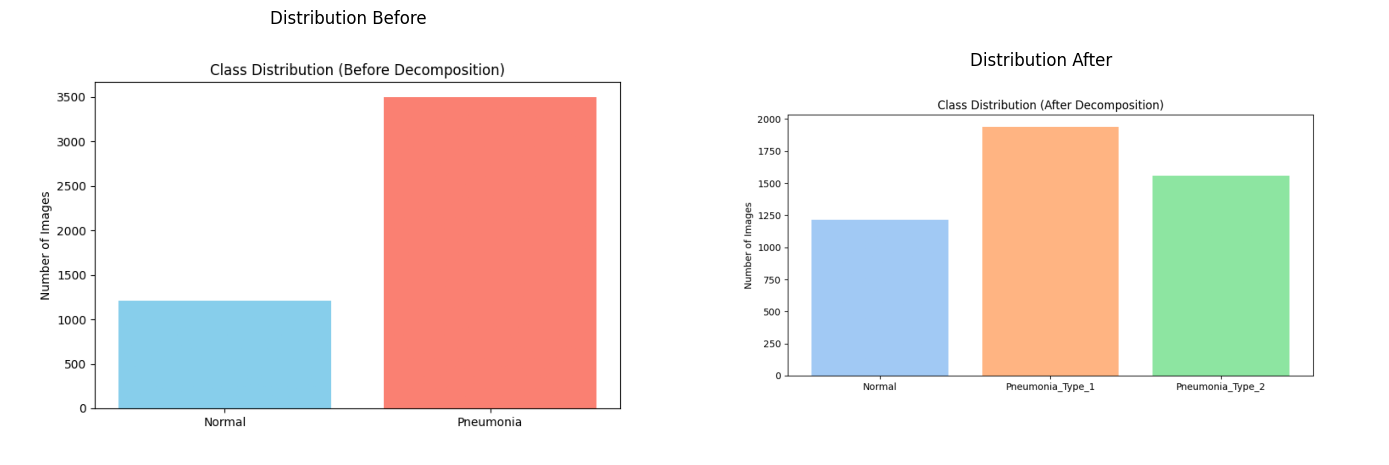

In [4]:
 import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# Define the file paths based on your directory structure
path_before = "/content/Task_1/results_decom/distribution_before.png"
path_after = "/content/Task_1/results_decom/distribution_after.png"

try:
    # Load the images
    img_before = mpimg.imread(path_before)
    img_after = mpimg.imread(path_after)

    # Set up the figure side-by-side (1 row, 2 columns)
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    # Plot the first image
    axes[0].imshow(img_before)
    axes[0].axis('off') # Hides the axes ticks
    axes[0].set_title("Distribution Before")

    # Plot the second image
    axes[1].imshow(img_after)
    axes[1].axis('off') # Hides the axes ticks
    axes[1].set_title("Distribution After")

    # Display the plots neatly
    plt.tight_layout()
    plt.show()

except FileNotFoundError as e:
    print(f"Error loading image: {e}\nPlease double-check that the files exist at the specified paths.")

# Test and Evaluation

In [5]:
%cd /content/Task_1/task1_classification
!python evaluate_decomp.py\
     --data_dir /content/pneumoniamnist_dataset\
         --model_path /content/Task_1/task1_classification/results_decom/best_model.pth\
             --output_dir results_test_decom

/content/Task_1/task1_classification
Evaluating on device: cuda:0
Running inference on test set with Binary Mapping...
--- Final Evaluation Metrics (Decomposition Applied) ---
Accuracy:  0.8638
Precision: 0.8835
Recall:    0.8638
F1-Score:  0.8562
AUC:       0.9783

--- Detailed Classification Report ---
              precision    recall  f1-score   support

      Normal       0.98      0.65      0.78       234
   Pneumonia       0.83      0.99      0.90       390

    accuracy                           0.86       624
   macro avg       0.90      0.82      0.84       624
weighted avg       0.88      0.86      0.86       624


Extracting failure cases...
Evaluation complete. All visualizations and metrics saved to results_test_decom


# Results

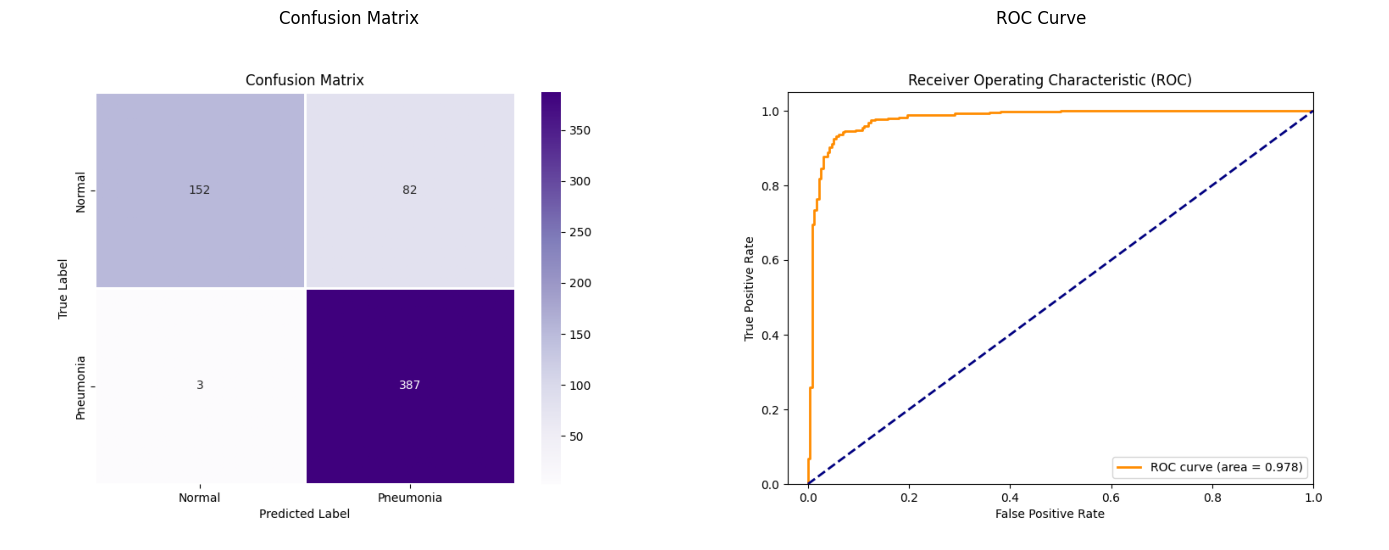

In [6]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# Define the file paths based on your request
path_cm = "/content/Task_1/task1_classification/results_test_decom/confusion_matrix.png"
path_roc = "/content/Task_1/task1_classification/results_test_decom/roc_curve.png"

try:
    # Load the images
    img_cm = mpimg.imread(path_cm)
    img_roc = mpimg.imread(path_roc)

    # Set up the figure side-by-side (1 row, 2 columns)
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    # Plot the Confusion Matrix
    axes[0].imshow(img_cm)
    axes[0].axis('off') # Hides the axes ticks
    axes[0].set_title("Confusion Matrix")

    # Plot the ROC Curve
    axes[1].imshow(img_roc)
    axes[1].axis('off') # Hides the axes ticks
    axes[1].set_title("ROC Curve")

    # Display the plots neatly
    plt.tight_layout()
    plt.show()

except FileNotFoundError as e:
    print(f"Error loading image: {e}\nPlease double-check that the files exist at the specified paths.")

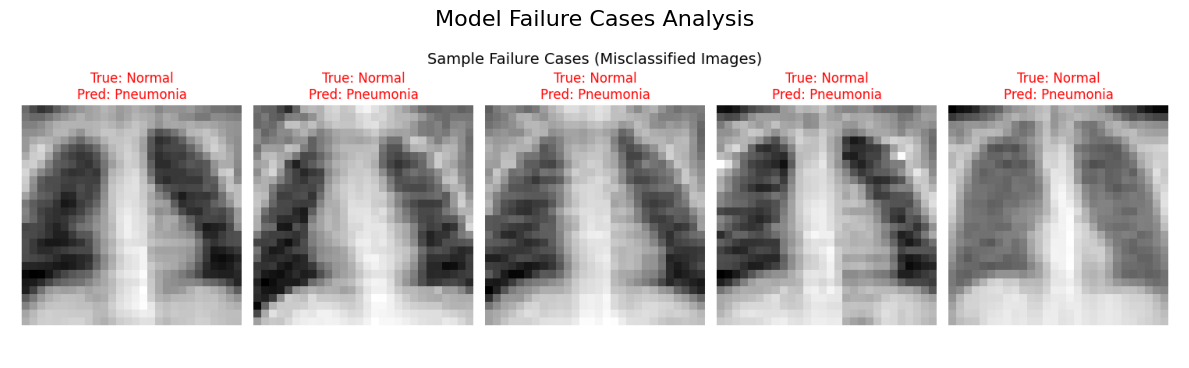

In [7]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# Define the file path
path_failures = "/content/Task_1/task1_classification/results_test_decom/failure_cases.png"

try:
    # Load the image
    img_failures = mpimg.imread(path_failures)

    # Set up the figure (making it a bit larger for readability)
    plt.figure(figsize=(12, 10))

    # Plot the Failure Cases image
    plt.imshow(img_failures)
    plt.axis('off') # Hides the axes ticks for a cleaner look
    plt.title("Model Failure Cases Analysis", fontsize=16, pad=15)

    # Display the plot neatly
    plt.tight_layout()
    plt.show()

except FileNotFoundError as e:
    print(f"Error loading image: {e}\nPlease double-check that the file exists at the specified path.")